# Notebook EDA – Chatbot Edukatif IPA Kelas 5
Notebook ini berisi loading data, cleaning, EDA, visualisasi, dan baseline retrieval sederhana.

In [1]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "data" / "datasoal.csv"
DATA_PATH


WindowsPath('c:/Users/muham/Downloads/procesdata/submission/data/datasoal.csv')

In [2]:
def read_dataset(path):
    encodings = ("utf-8-sig", "utf-8", "latin1")
    last_error = None
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception as exc:
            last_error = exc
    raise last_error

def normalize_columns(df):
    df = df.copy()
    df.columns = [str(c).strip().lower().replace(" ", "_") for c in df.columns]
    for col in list(df.columns):
        if col.replace("_", " ") == "link sumber buku":
            df = df.rename(columns={col: "link_sumber_buku"})
    return df

def clean_text(value):
    if pd.isna(value):
        return ""
    text = str(value).lower().strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[“”\"'`]", "", text)
    text = re.sub(r"[^0-9a-zA-ZÀ-ÿ\s\-\?\!\,\.\:\;\(\)]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def prepare_dataset(df):
    df = normalize_columns(df)
    for col in ["topik", "subtopik", "soal", "jawaban", "contoh", "konteks", "link_sumber_buku"]:
        if col not in df.columns:
            df[col] = ""
    if "no" not in df.columns:
        df["no"] = range(1, len(df) + 1)
    for col in ["topik", "subtopik", "soal", "jawaban", "contoh", "konteks"]:
        df[col] = df[col].astype(str).map(clean_text)
    df["soal_len"] = df["soal"].str.split().map(len)
    df["jawaban_len"] = df["jawaban"].str.split().map(len)
    df = df.drop_duplicates(subset=["soal", "jawaban"]).reset_index(drop=True)
    df["no"] = range(1, len(df) + 1)
    return df

df_raw = read_dataset(DATA_PATH)
df = prepare_dataset(df_raw)
df.head()


,no,topik,subtopik,soal,jawaban,contoh,konteks,link_sumber_buku,soal_len,jawaban_len
0,1,organ tubuh manusia dan hewan,alat pernapasan pada manusia,sebutkan alat pernapasan pada manusia!,rongga hidung berfungsi sebagai pintu masuk ud...,"udara masuk melalui hidung, lalu melewati trak...",manusia bernapas dengan bantuan beberapa organ...,https://www.omahbse.com/ktsp/file/sd-5_ipa_002/,5,19
1,2,organ tubuh manusia dan hewan,fungsi rongga hidung,apa fungsi rongga hidung saat bernapas?,rongga hidung berfungsi untuk menyaring debu s...,rambut hidung dan selaput lendir menahan kotor...,udara yang masuk ke hidung tidak langsung menu...,https://www.omahbse.com/ktsp/file/sd-5_ipa_002/,6,14
2,3,organ tubuh manusia dan hewan,pernapasan dada dan perut,apa perbedaan pernapasan dada dan pernapasan p...,pernapasan dada terjadi karena pergerakan tula...,"saat tulang rusuk terangkat, rongga dada membe...",gerak otot-otot pernapasan membuat udara dapat...,https://www.omahbse.com/ktsp/file/sd-5_ipa_002/,7,14
3,4,organ tubuh manusia dan hewan,alat pernapasan ikan,dengan alat apa ikan bernapas?,ikan menggunakan insang untuk mengambil oksige...,"mulut ikan terbuka dan air masuk, lalu oksigen...",ikan hidup di air sehingga menggunakan insang ...,https://www.omahbse.com/ktsp/file/sd-5_ipa_002/,5,8
4,5,organ tubuh manusia dan hewan,alat pernapasan burung,apa alat bantu pernapasan burung saat terbang?,pundi udara membantu proses pernapasan ketika ...,pundi-pundi udara membantu burung tetap bernap...,burung memiliki sistem pernapasan yang menduku...,https://www.omahbse.com/ktsp/file/sd-5_ipa_002/,7,10


In [3]:
df.shape, df.columns.tolist()


((566, 10),
 ['no',
  'topik',
  'subtopik',
  'soal',
  'jawaban',
  'contoh',
  'konteks',
  'link_sumber_buku',
  'soal_len',
  'jawaban_len'])

In [4]:
df.isna().sum()


no                  0
topik               0
subtopik            0
soal                0
jawaban             0
contoh              0
konteks             0
link_sumber_buku    0
soal_len            0
jawaban_len         0
dtype: int64

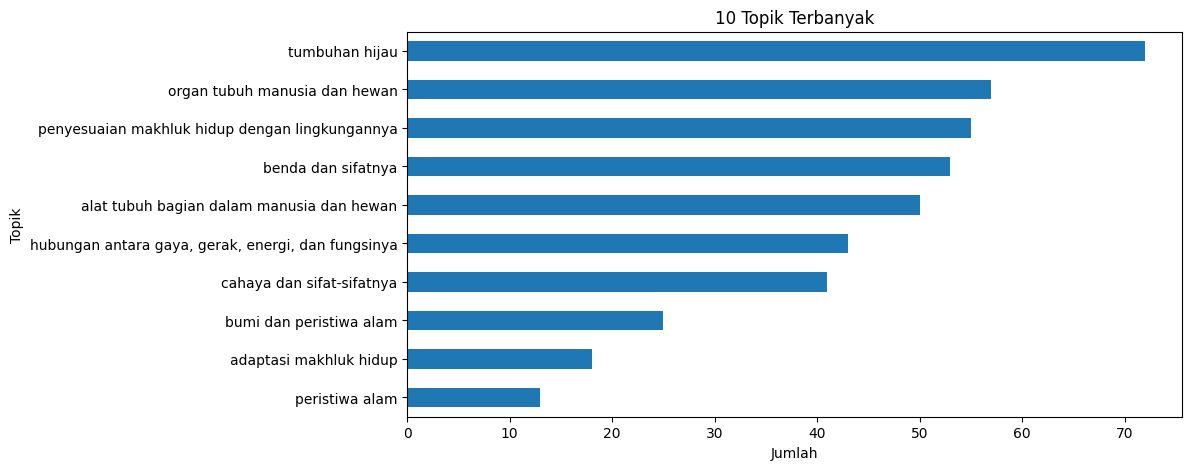

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
df["topik"].value_counts().head(10).sort_values().plot(kind="barh", ax=ax)
ax.set_title("10 Topik Terbanyak")
ax.set_xlabel("Jumlah")
ax.set_ylabel("Topik")
plt.show()


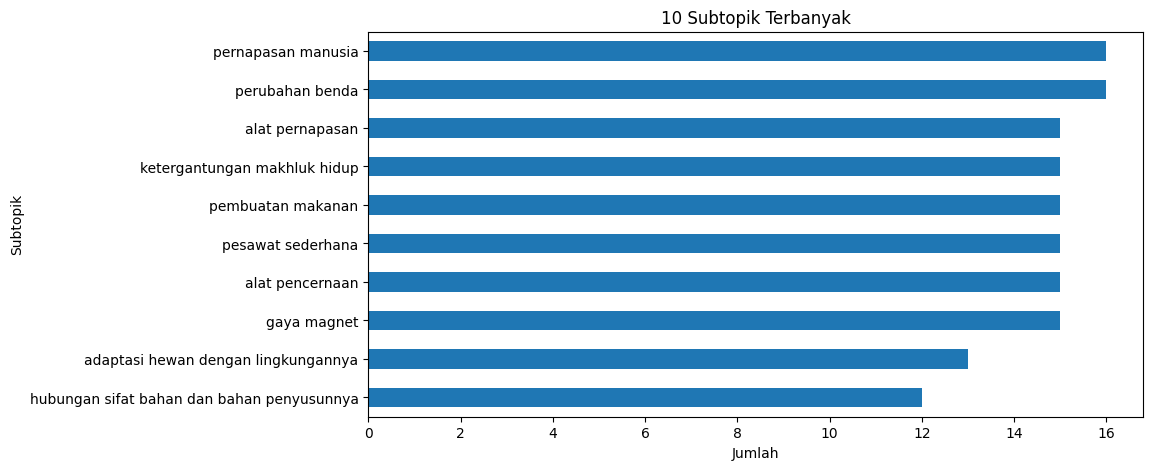

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
df["subtopik"].value_counts().head(10).sort_values().plot(kind="barh", ax=ax)
ax.set_title("10 Subtopik Terbanyak")
ax.set_xlabel("Jumlah")
ax.set_ylabel("Subtopik")
plt.show()


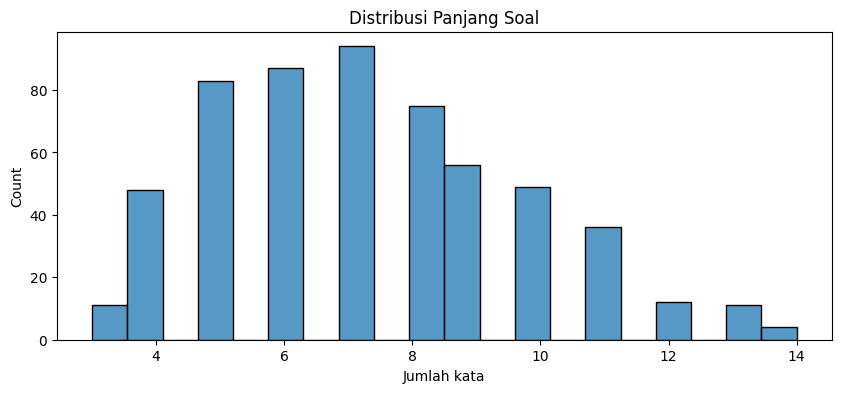

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df["soal_len"], bins=20, ax=ax)
ax.set_title("Distribusi Panjang Soal")
ax.set_xlabel("Jumlah kata")
plt.show()


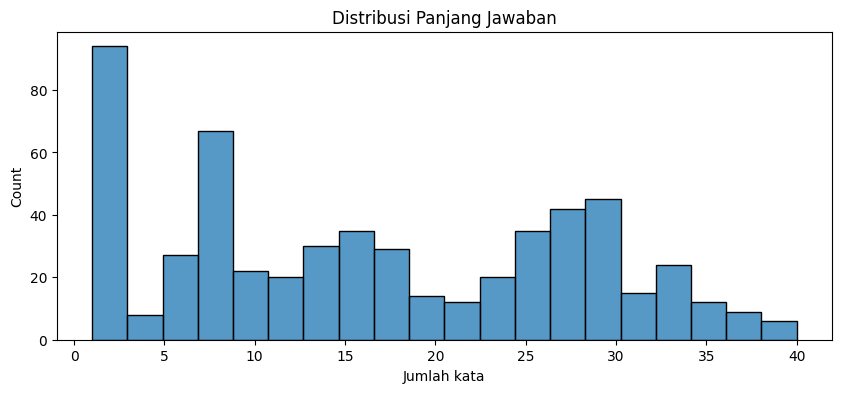

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df["jawaban_len"], bins=20, ax=ax)
ax.set_title("Distribusi Panjang Jawaban")
ax.set_xlabel("Jumlah kata")
plt.show()


In [9]:
corpus = (df["soal"] + " " + df["jawaban"]).tolist()
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=6000)
matrix = vectorizer.fit_transform(corpus)

def retrieve_answer(query):
    q_vec = vectorizer.transform([clean_text(query)])
    scores = cosine_similarity(q_vec, matrix).flatten()
    idx = scores.argmax()
    return df.iloc[idx], scores[idx]

sample_query = "Apa fungsi akar pada tumbuhan?"
best_row, score = retrieve_answer(sample_query)
score, best_row[["topik", "subtopik", "soal", "jawaban"]]


(0.48353605880484407,
 topik                                          tumbuhan hijau
 subtopik                                      bagian tumbuhan
 soal                           apa fungsi akar pada tumbuhan?
 jawaban     akar berfungsi menyerap air dan zat hara dari ...
 Name: 373, dtype: object)

## Kesimpulan
Notebook ini bisa dipakai untuk EDA awal dan baseline retrieval sebelum integrasi ke chatbot.